In [14]:
import subprocess
import sys
import re
import os
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import seaborn.objects as so
import warnings
warnings.filterwarnings("ignore")

### Compile, set up and run the code

In [15]:
structFileName = "struct.dat"
evolveFileName = "evo.dat"
runcmd = f"./PlanetSolver -cn 1 0.2925 -en 2 0.607495 -a 8.9 30 0.1 -s 1 1 1 0.3 -m 8.0 -evolve 1 -struct {structFileName} -wr {evolveFileName}"


In [16]:
result = subprocess.run(
"make clean", 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    raise OSError("OS could not handle make clean")

result = subprocess.run(
"make", 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    raise OSError("Could not make")

result = subprocess.run(
runcmd, 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    raise OSError("Runtime error")



### View the modeled evolution

In [17]:
input_col_names = ['Age', 'Atmospheric Entropy', 'Radius', 'Mass', 'delta_M', 'AMF', 'T_eff']
with open(evolveFileName, 'r') as file:
        lines = file.readlines()
data_start_idx = None
header_lines = []
    
for i, line in enumerate(lines):
    line = line.strip()
    # Look for the characteristic column headers
    if 'Age (Myr)' in line and 'Entropy' in line and 'Radius' in line:
        data_start_idx = i+1 #skips heading column
        break
    else:
        header_lines.append(line)

evodf = pd.read_table(evolveFileName, skiprows=data_start_idx, names=input_col_names, sep=" ")

In [18]:
evodf

,Age,Atmospheric Entropy,Radius,Mass,delta_M,AMF,T_eff
0,0.000000,8.40000,9.41637,8.00012,0.000000,0.100000,0.0000
1,0.095483,8.39000,5.48765,8.00004,0.000074,0.099992,368.5350
2,0.383932,8.38000,5.44776,8.00000,0.000048,0.099986,365.8620
3,0.684212,8.37000,5.40857,7.99995,0.000048,0.099981,363.2100
4,0.996787,8.36000,5.37015,7.99990,0.000049,0.099975,360.5700
...,...,...,...,...,...,...,...
286,13687.400000,6.21400,2.75180,7.75227,0.000013,0.071226,73.0762
287,13787.400000,6.21075,2.75031,7.75226,0.000013,0.071225,72.8552
288,13887.400000,6.20753,2.74910,7.75225,0.000013,0.071223,72.6732
289,13987.400000,6.20433,2.74779,7.75224,0.000013,0.071222,72.5235


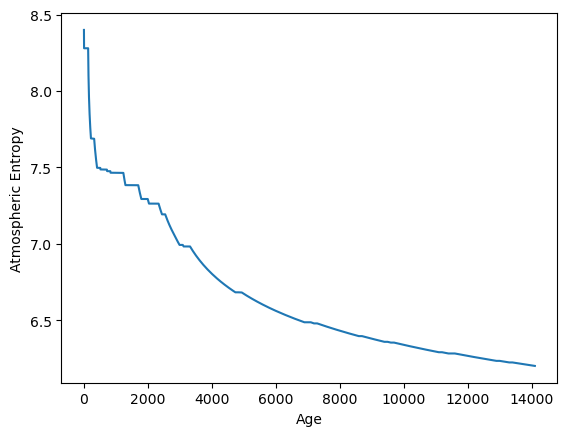

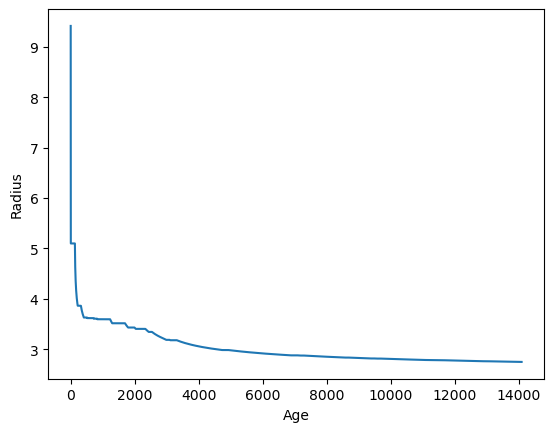

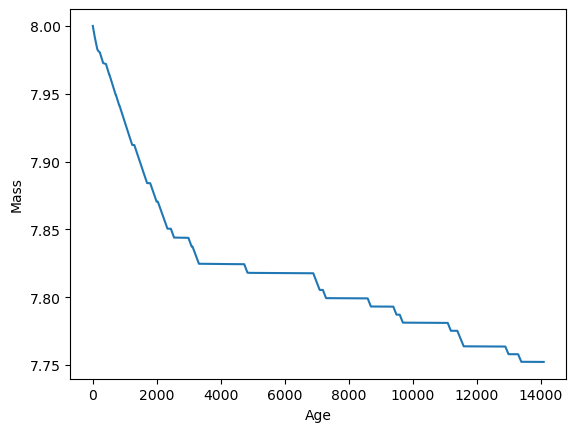

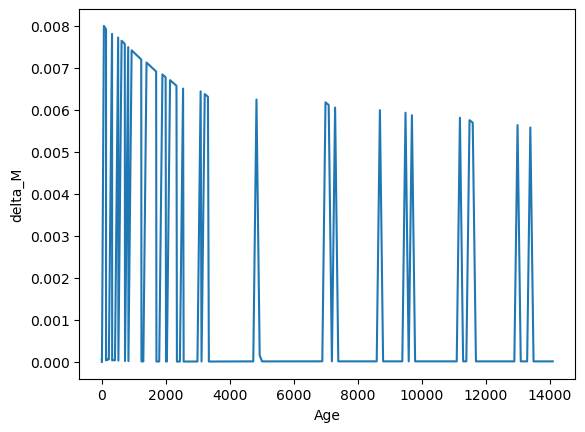

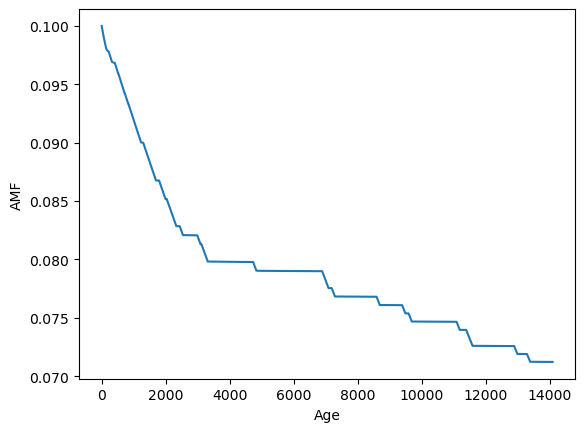

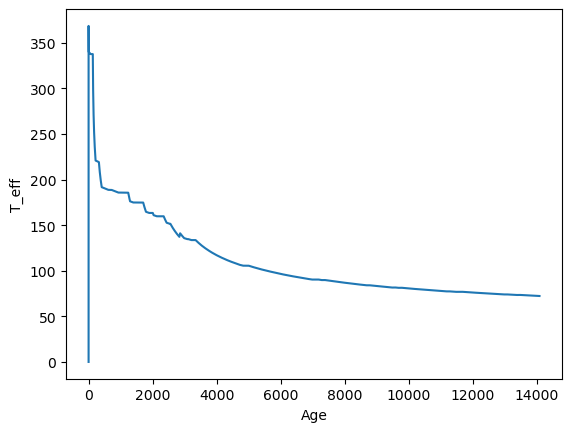

In [20]:
for col in input_col_names:
    if col == "Age":
        continue
    sns.lineplot(data = evodf, x = 'Age', y = col)
    plt.show()